In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap


In [2]:
transcriptomics_data = "../data/0_data_for_mlp/TCGA-BRCA.star_tpm.csv"
clinical_data = "../data/clinical_data/brca_clinical/all_samples.csv"

In [3]:
expr = pd.read_csv(transcriptomics_data, index_col=0)
meta = pd.read_csv(clinical_data)

In [4]:
meta = meta.set_index("case_id")
common = expr.index.intersection(meta.index)

In [5]:
expr = expr.loc[common]
meta = meta.loc[common]


In [6]:
# === 3. Standaryzacja ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(expr)

In [7]:
# === 4. PCA ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

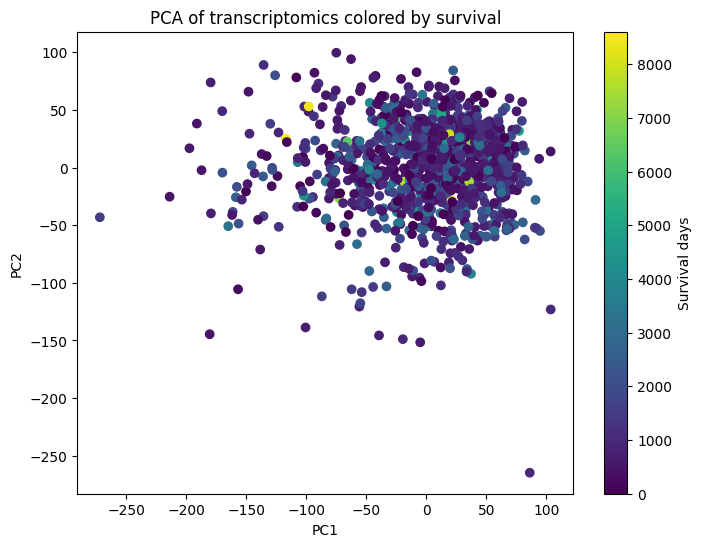

In [8]:
# === 5. Plot ===
plt.figure(figsize=(8,6))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=meta["dss_survival_days"],
    cmap="viridis"
)

plt.colorbar(sc, label="Survival days")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of transcriptomics colored by survival")

plt.show()